In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']

import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
from scipy.stats import boxcox
from scipy.special import inv_boxcox

import jax.numpy as jnp
from train_diffusion import *
import jax.random as random
rng = random.PRNGKey(2025)

import seaborn as sns
gt_color = np.array((59, 124, 243))/256
pr_color = np.array((117, 251, 76))/256

In [2]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)

# Training a diffusion model on the raw data - Of course not going to work

In [3]:
# Normalize the data
data_normalized = []
fitted_lambdas = []
means_stds = []
for i in range(n_ingr):
    transformed, fitted_lambda = boxcox(recipes[:,i] + 1e-8)
    mean, std = transformed.mean(), transformed.std()
    transformed = (transformed - mean)/std
    data_normalized.append(transformed)
    fitted_lambdas.append(fitted_lambda)
    means_stds.append([mean, std])
data_normalized = jnp.array(data_normalized).T

def transform_back(transformed_recipe):
    recipe = []
    for i in range(n_ingr):
        fitted_lambda = fitted_lambdas[i]
        mean, std = means_stds[i]
        temp = transformed_recipe[i]*std + mean
        temp = inv_boxcox(temp, fitted_lambda)
        recipe.append(temp)
    return jnp.array(recipe)

/Users/vtac/vtenv/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


In [ ]:
batch_size = 100
#some dummy input data. Flax is able to infer all the dimensions of the weights
#if we supply if with the kind of input data it has to expect
x = jnp.zeros((data_normalized.shape[1])*batch_size).reshape((batch_size, data_normalized.shape[1]))
time = jnp.ones((batch_size, 1))
#initialize the model weights
score_model = ApproximateScore() # from diffusion_utils
params = score_model.init(rng, x, time) # from diffusion_utils
#Initialize the optimizer
optimizer = optax.adam(5.e-4)
opt_state = optimizer.init(params)
N_epochs = 10000
train_size = data_normalized.shape[0]
batch_size = 20
batch_size = min(train_size, batch_size)
steps_per_epoch = train_size // batch_size

params = train_diffusion(data_normalized, score_model, N_epochs, train_size, batch_size, steps_per_epoch, rng, params, optimizer, opt_state)
with open('params/diff_params_.npy', 'wb') as f:
    pickle.dump(params, f)

# Sample using the trained params
trained_score = lambda x, t: score_model.apply(params, x, t)
rng, step_rng = random.split(rng)
samples = reverse_sde(step_rng, data_normalized.shape[1], 100, drift, dispersion, trained_score)

In [ ]:
test = transform_back(samples[3])

plt.figure(figsize=(20,5))
plt.bar(ingr_names,test)

plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

# Train 2 models - one to predict the mask, another to predict quantities

# 1. Mask models

## 1.1. Autoregressive scheme based on causal transformers - doesn't work

In [175]:
from train_transformer import *

In [176]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
with open('params/inputs_params.npy', 'rb') as f:
    data_normalized, fitted_lambdas, means_stds, gt_mask, gt_vals = pickle.load(f)
n_recipes = data_normalized.shape[0]
n_ingr = data_normalized.shape[1]

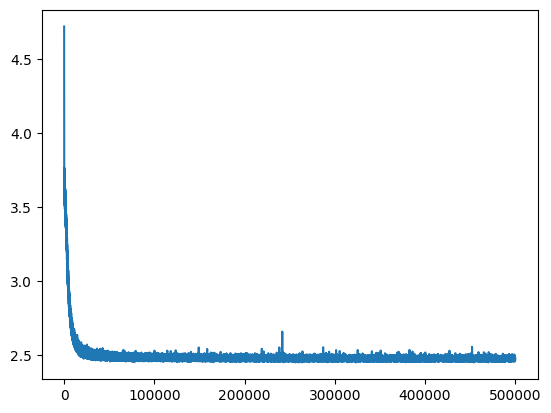

In [177]:
D = n_ingr # dimensionality of the data (I am assuming)
batch_size = 100
K = 20 # The number of gaussian features used (assume)

# load mask model state
rng, m_init_rng = jax.random.split(rng)
mask_model = MaskAR(D=D)
mask_state = create_train_state(m_init_rng, mask_model, (gt_mask[:batch_size],))
with open('params/mask_params.npy', 'rb') as f:
    mask_params, m_metrics_hist = pickle.load(f)
mask_state = mask_state.replace(params=mask_params)

# Plot loss
m_loss = [metric['loss'] for metric in m_metrics_hist]
plt.plot(np.log(m_loss))

### 1.1.1. Some samples for a quick glance

In [178]:
with open(f'params/samples.npy', 'rb') as f:
    aux = pickle.load(f)
sampled_masks = []
for i in range(len(aux)):
    sampled_masks.extend(aux[i])
sampled_masks = np.array(sampled_masks)

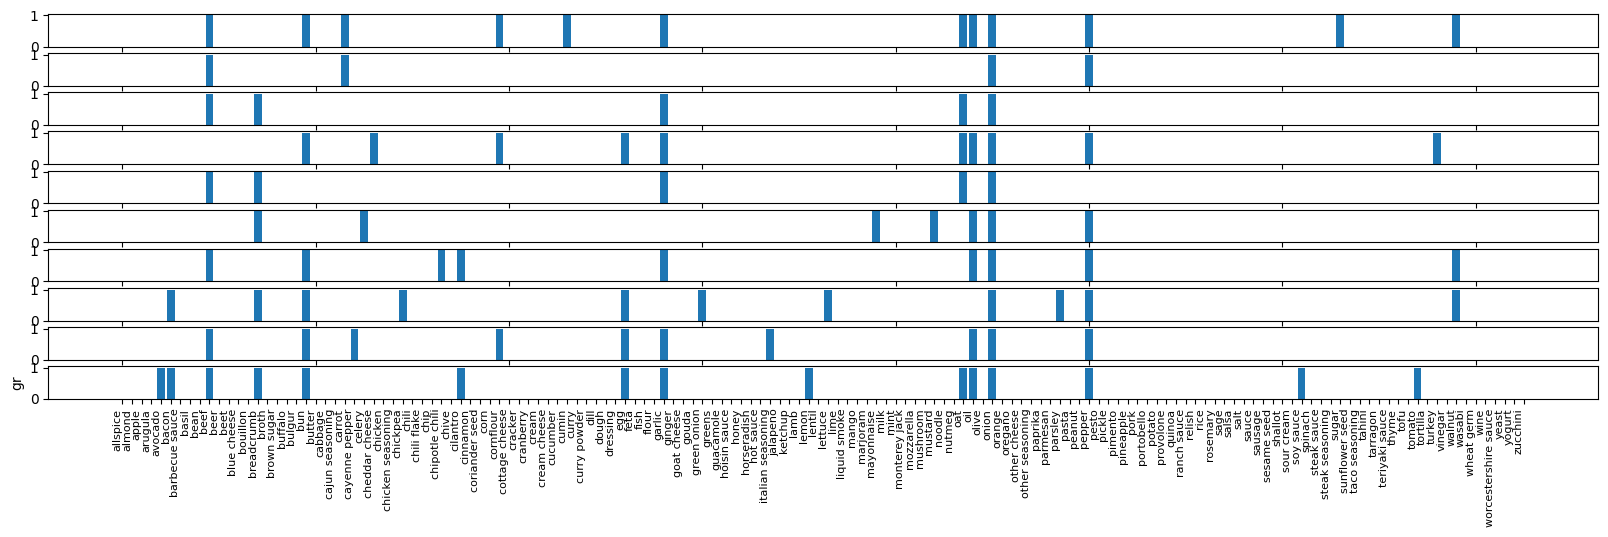

In [179]:
n = 10
plt.figure(figsize=(20,0.5*n))
for i in range(n):
    plt.subplot(n, 1, i+1)
    plt.bar(np.arange(sampled_masks.shape[1]), sampled_masks[i])

plt.gca().set_xticks(range(len(ingr_names)))
plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

### 1.1.2. What `pos_weight` to use?

I included a weighting parameter called pos_weight to help with the class imbalance problem. However, the value of this parameter is critical.

To help identify what value to use, run 7_train_transformer.py multiple times with multiple values of pos_weights. Choose the pos_weight value that satisfies this: the average number of ingredients per recipe in a large number of samples should be roughly equal to the ground truth data.

Average number of ingredients per recipe (ground truth):  9.288357400722022
pos_weight   |   Average number of ingredients per recipe (sampled)
----------------------------------------------------------------------
1.0    |   8.818244444444444
2.0    |   9.814
3.0    |   11.242444444444445
4.0    |   9.7432
5.0    |   11.535777777777778
6.0    |   11.451644444444444
7.0    |   10.22331111111111
8.0    |   12.520088888888889
9.0    |   11.74848888888889
10.0    |   14.261533333333333


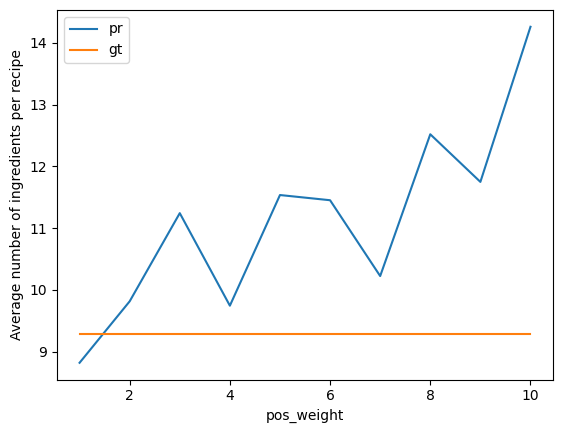

In [180]:
print("Average number of ingredients per recipe (ground truth): ", np.mean(gt_mask.sum(axis=1)))
print("pos_weight   |   Average number of ingredients per recipe (sampled)")
print('-'*70)

pr = []
for pos_weight in np.arange(1.0,11.0):
    sampled_masks = []
    for part in np.arange(1,10):
        with open(f'params/samples_pos_weight_{pos_weight}_part_{part}.npy', 'rb') as f:
            sampled_masks.extend(pickle.load(f))
    sampled_masks = np.array(sampled_masks)
    
    sampled_n_ingr = sampled_masks.sum(axis=1)
    print(f"{pos_weight}    |   {sampled_n_ingr.mean()}")
    pr.append(sampled_n_ingr.mean())

plt.plot(np.arange(1.0,11.0), pr, label = 'pr')
plt.plot(np.arange(1.0,11.0), [np.mean(gt_mask.sum(axis=1))]*10, label = 'gt')
plt.xlabel('pos_weight')
plt.ylabel('Average number of ingredients per recipe')
plt.legend()

It looks like I should not be using a pos_weight at all (i.e. pos_weight=1).

### 1.1.3. Marginal probability of each ingredient

But how many samples do you need to take before marginal probabilities stabilize?

Look at more and more samples until marginal probabilities stop changing.

n samples, maximum absolute diff (|p-p_prev|)
10000 , 0.7699999999999929 %
15000 , 0.7099999999999995 %
20000 , 0.3616666666666657 %
25000 , 0.3139999999999976 %
30000 , 0.19200000000000328 %
35000 , 0.1747619047619109 %
40000 , 0.16250000000000153 %
45000 , 0.1188888888888906 %


Text(0, 0.5, 'max absolute diff: max(|p-p_prev|) [%]')

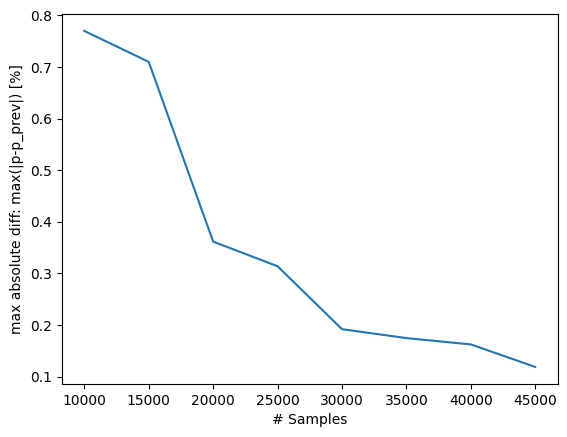

In [181]:
prev_probs = sampled_masks[:5000].sum(axis=0)/5000
print('n samples, maximum absolute diff (|p-p_prev|)')

n_samples = np.arange(10000, len(sampled_masks)+1, 5000)
aux = []
for i in n_samples: # how many samples to include in each step
    probs = sampled_masks[:i].sum(axis=0)/i
    mae = np.max(np.abs(probs-prev_probs))
    print(i, ',', mae*100, '%')
    prev_probs = probs.copy()
    aux.append(mae)

plt.plot(n_samples, np.array(aux)*100)
plt.xlabel('# Samples')
plt.ylabel('max absolute diff: max(|p-p_prev|) [%]')

Conclusion: Looks like even 25000 samples is more than enough, because the outcomes stop changing noticably.

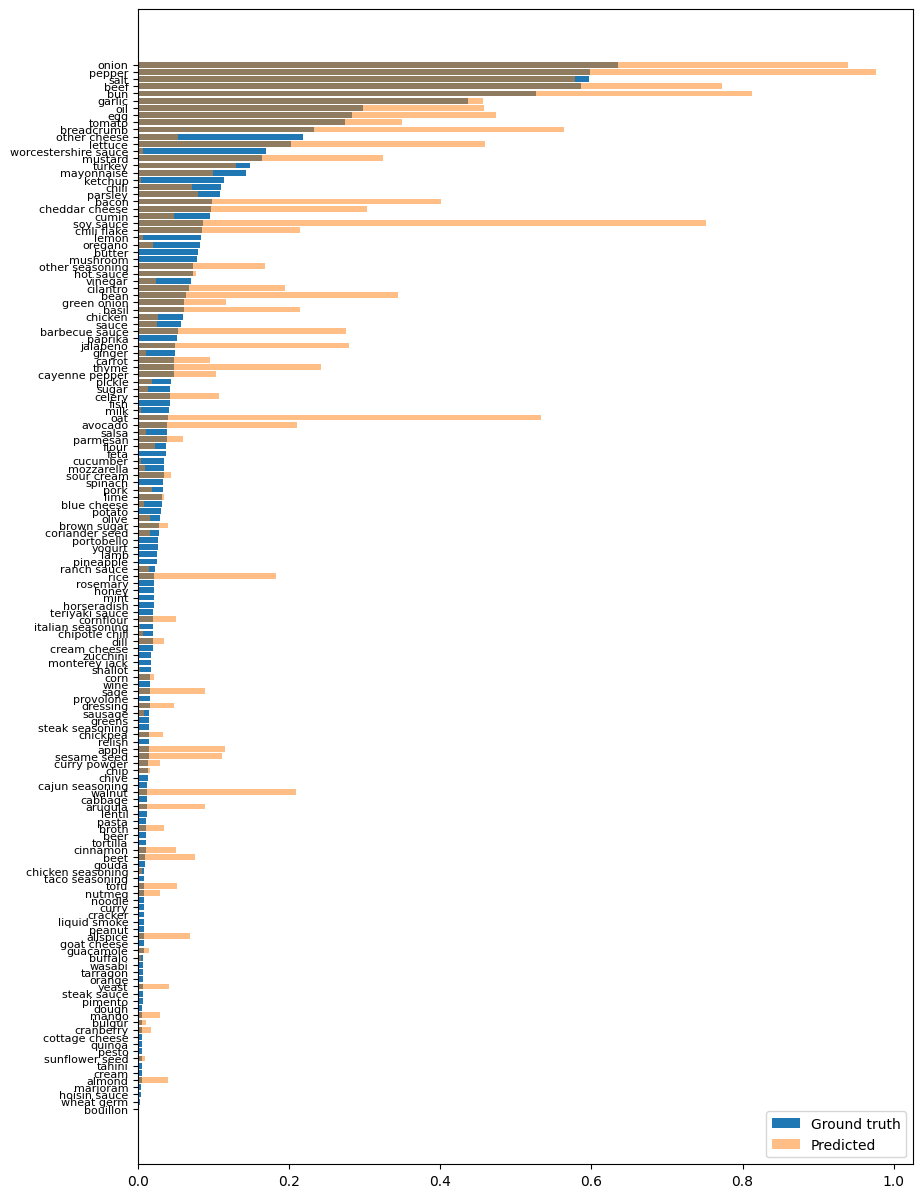

In [182]:
plt.figure(figsize=(10,15))

gt_probs = gt_mask.sum(axis=0)/len(gt_mask)
idx_sorted = np.argsort(gt_probs)
plt.barh(np.arange(gt_mask.shape[1]), gt_probs[idx_sorted], label='Ground truth')

pr_probs = sampled_masks.sum(axis=0)/len(sampled_masks)
plt.barh(np.arange(gt_mask.shape[1]), pr_probs[idx_sorted], label='Predicted', alpha=0.5)

plt.gca().set_yticks(range(len(ingr_names)))
plt.gca().set_yticklabels(ingr_names[idx_sorted], ha='right', fontsize=8); 
plt.legend(loc='lower right')

### 1.1.4. Simpler model with disjoint bernoullis

The graph above shows that the model is not even capturing the marginal probabilities of the ingredients. I think even assigning independent bernoullis to each ingredient should work better than this, let's test it

In [183]:
with open('params/mask_params_pos_weight_1.0.npy', 'rb') as f:
    mask_params, m_metrics_hist = pickle.load(f)

gt_logits = np.log(gt_probs/(1-gt_probs))
gt_logits = np.clip(gt_logits, -1000.0, 1000.0)

def disjointbernoulli(inputs):
    batch_size = len(inputs)
    return jnp.broadcast_to(gt_logits, (batch_size, len(gt_logits)))

def loss_fn(batch_m, model): # This is adopted from inside train_step_mask
    inputs, labels = make_inputs_and_labels(batch_m, 0.0, 0.0)
    logits = model(inputs)
    loss = mask_loss_fn(logits, labels)
    return loss

ar_model = lambda inputs: MaskAR(D=gt_mask.shape[1]).apply({'params': mask_params}, inputs, deterministic=False, rngs={'dropout': rng})

batch_size = 1000
batch_idx = jax.random.choice(rng, jnp.arange(len(gt_mask)), shape=(batch_size,))
batch = gt_mask[batch_idx]

loss1 = loss_fn(batch, ar_model)
loss2 = loss_fn(batch, disjointbernoulli)

print(f"Transformer loss: {loss1}")
print(f"Disjoint bernoulli model loss: {loss2}")

/var/folders/9y/21x449m536x_ksj1_w7hvk9c0000gq/T/ipykernel_22164/3603618306.py:4: RuntimeWarning: divide by zero encountered in log
  gt_logits = np.log(gt_probs/(1-gt_probs))


Transformer loss: 7.8833327293396
Disjoint bernoulli model loss: 24.710986684396655


interesting... 

lets try sampling...

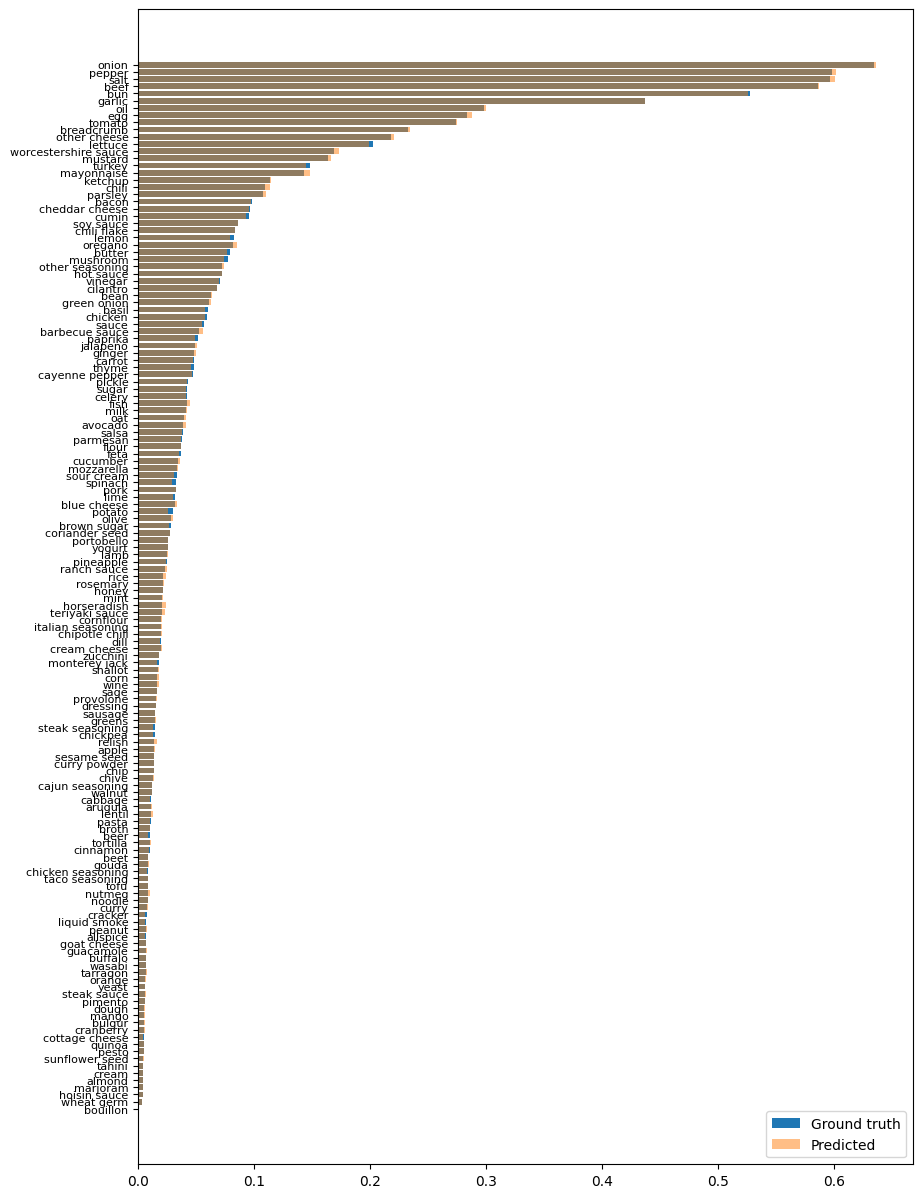

In [184]:
bernoulli_samples = disjointbernoulli(np.zeros(10000))
bernoulli_samples = jax.nn.sigmoid(bernoulli_samples)
bernoulli_samples = jax.random.bernoulli(rng, bernoulli_samples)


plt.figure(figsize=(10,15))
plt.barh(np.arange(gt_mask.shape[1]), gt_probs[idx_sorted], label='Ground truth')

pr_probs = bernoulli_samples.sum(axis=0)/len(bernoulli_samples)
plt.barh(np.arange(gt_mask.shape[1]), pr_probs[idx_sorted], label='Predicted', alpha=0.5)

plt.gca().set_yticks(range(len(ingr_names)))
plt.gca().set_yticklabels(ingr_names[idx_sorted], ha='right', fontsize=8); 
plt.legend(loc='lower right')

## 1.2. Ad-hoc adaptation of score-based continuous diffusion model - also doesn't work

In [2]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)
gt_mask = jnp.array(recipes>0, dtype='int32')

In [ ]:
batch_size = 400
# Initialize the score function with some dummy input data of the right shape
score_model = ApproximateScore(n_hidden=1000) # from diffusion_utils
params = score_model.init(rng, x = jnp.zeros([batch_size, n_ingr]), t = jnp.ones((batch_size, 1)))

N_epochs = 10000
#Initialize the optimizer
schedule = optax.cosine_decay_schedule(
    init_value=5e-4,    # starting LR
    decay_steps=N_epochs, # total steps to decay over
    alpha=0.01          # final LR = alpha * init_value
)
# optimizer = optax.adam(5.e-4)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)

train_size = n_recipes
batch_size = min(train_size, batch_size)
steps_per_epoch = train_size // batch_size

params = train_diffusion(gt_mask, score_model, N_epochs, train_size, batch_size, steps_per_epoch, rng, params, optimizer, opt_state)
with open('params/diff_mask_params.npy', 'wb') as f:
    pickle.dump(params, f)

# Sample using the trained params
trained_score = lambda x, t: score_model.apply(params, x, t)
rng, step_rng = random.split(rng)
samples = reverse_sde(step_rng, n_ingr, 25000, drift, dispersion, trained_score).block_until_ready()

In [170]:
with open('params/diff_mask_params_epochs_5000_lr_0.001.npy', 'rb') as f:
    params = pickle.load(f)
with open('params/diff_mask_samples_epochs_5000_lr_0.001.npy', 'rb') as f:
    samples = pickle.load(f)

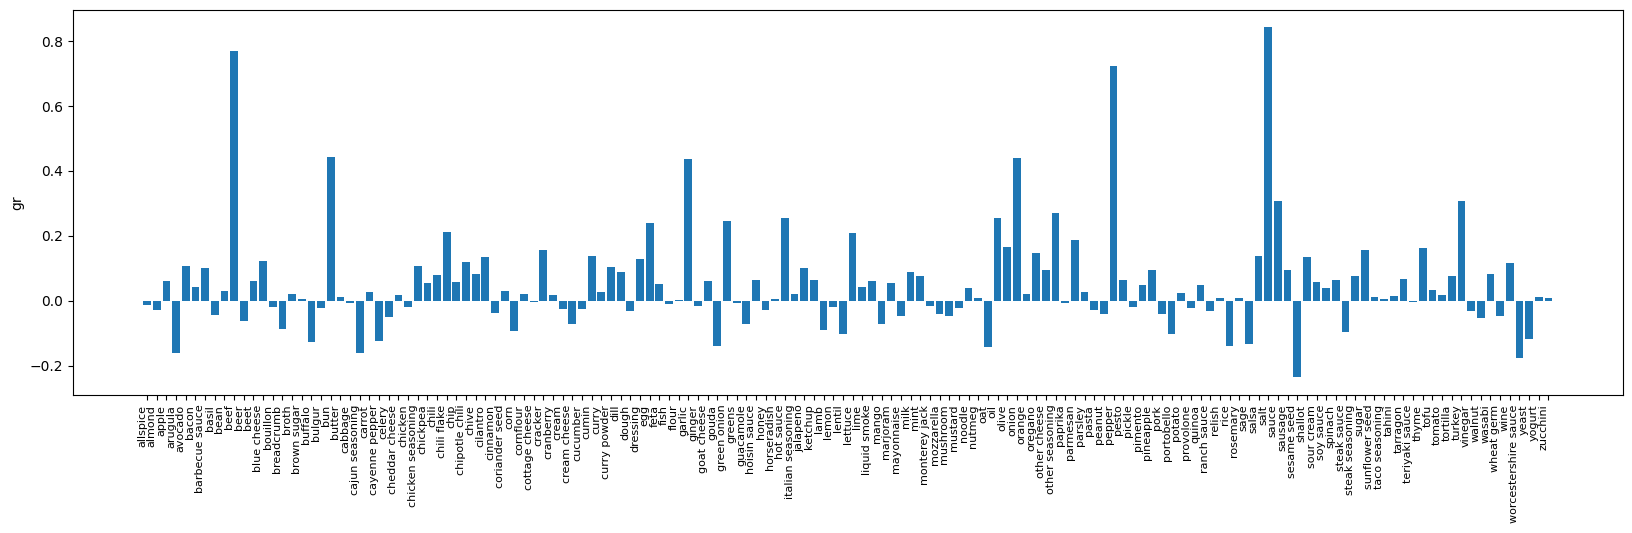

In [171]:
test = samples[0]

plt.figure(figsize=(20,5))
plt.bar(ingr_names,test)

plt.gca().set_xticks(range(len(ingr_names)))
plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

In [172]:
sampled_probs = np.clip(samples, 0.0, 1.0)
sampled_masks = jax.random.bernoulli(rng, sampled_probs)

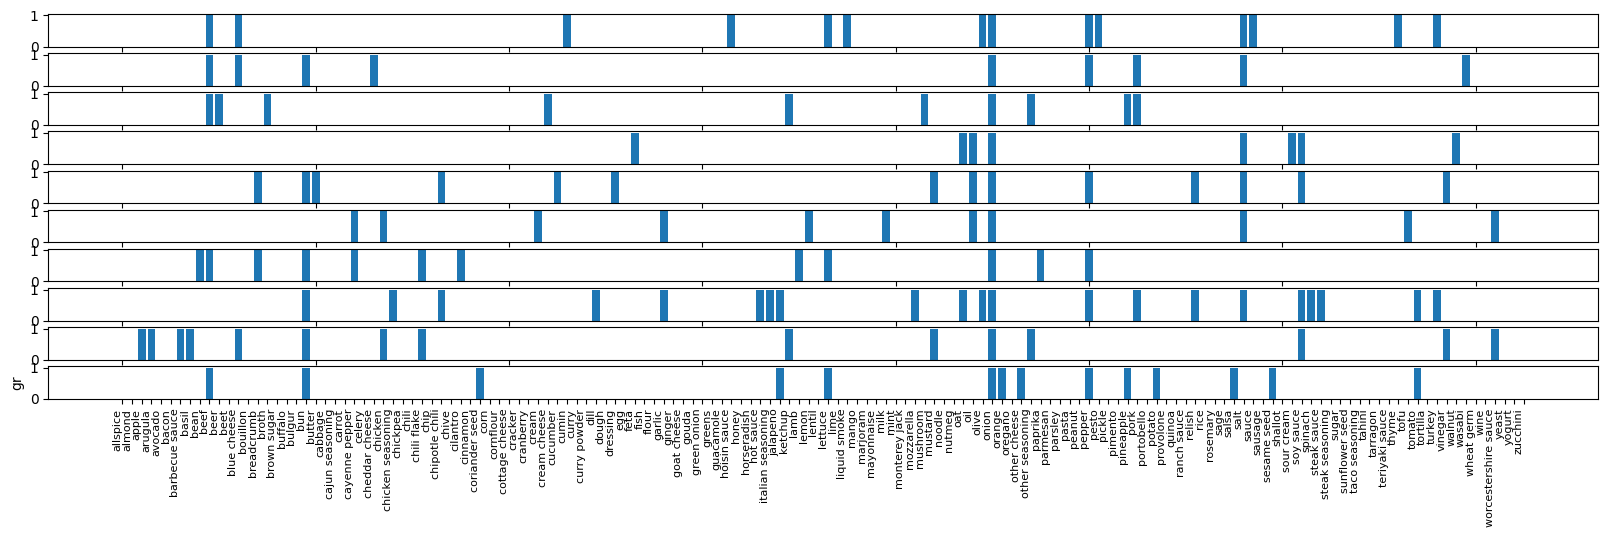

In [173]:
plt.figure(figsize=(20,5))
for i in range(10):
    plt.subplot(10, 1, i+1)
    plt.bar(np.arange(n_ingr), sampled_masks[i])

plt.gca().set_xticks(range(len(ingr_names)))
plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

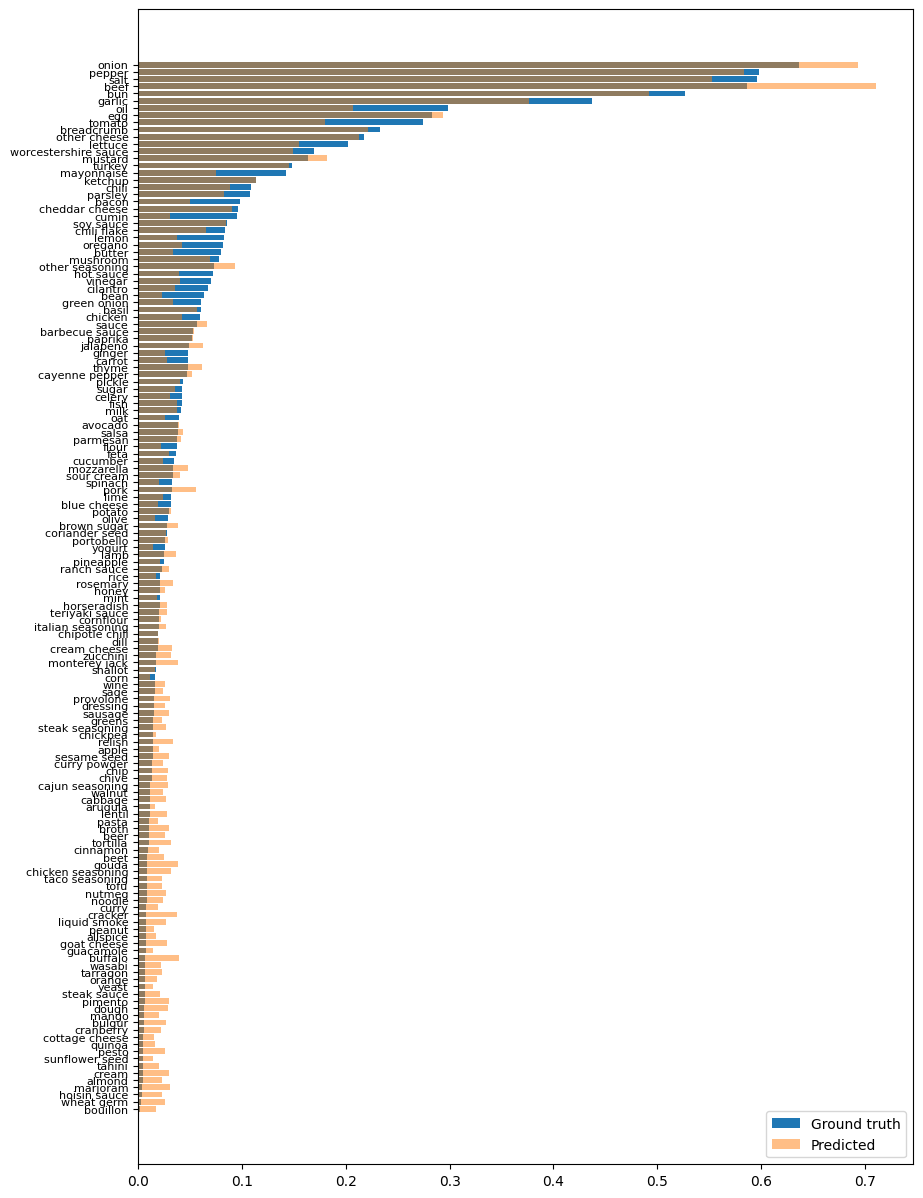

In [124]:
plt.figure(figsize=(10,15))

gt_probs = gt_mask.sum(axis=0)/len(gt_mask)
idx_sorted = np.argsort(gt_probs)
plt.barh(np.arange(gt_mask.shape[1]), gt_probs[idx_sorted], label='Ground truth')

pr_probs = sampled_probs.mean(axis=0)
plt.barh(np.arange(gt_mask.shape[1]), pr_probs[idx_sorted], label='Predicted', alpha=0.5)

plt.gca().set_yticks(range(len(ingr_names)))
plt.gca().set_yticklabels(ingr_names[idx_sorted], ha='right', fontsize=8); 
plt.legend(loc='lower right')

n samples, maximum absolute diff (|p-p_prev|)
10000 , 0.8099999999999996 %
15000 , 0.3766666666666668 %
20000 , 0.3166666666666679 %
25000 , 0.2990000000000048 %
30000 , 0.22533333333333294 %
35000 , 0.1371428571428579 %
40000 , 0.1492857142857129 %
45000 , 0.23194444444444295 %
50000 , 0.18755555555555747 %


Text(0, 0.5, 'max absolute diff: max(|p-p_prev|) [%]')

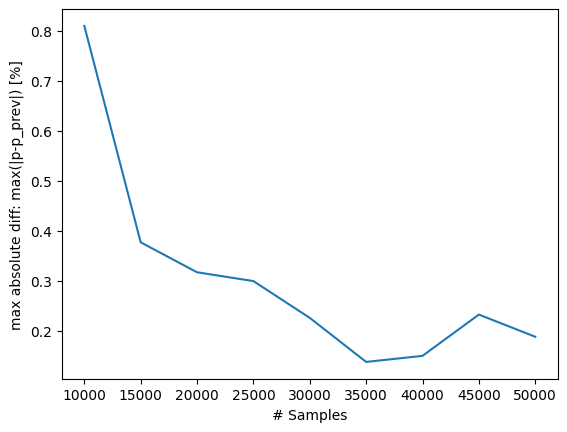

In [125]:
prev_probs = sampled_masks[:5000].sum(axis=0)/5000
print('n samples, maximum absolute diff (|p-p_prev|)')

n_samples = np.arange(10000, len(sampled_masks)+1, 5000)
aux = []
for i in n_samples: # how many samples to include in each step
    probs = sampled_masks[:i].sum(axis=0)/i
    mae = np.max(np.abs(probs-prev_probs))
    print(i, ',', mae*100, '%')
    prev_probs = probs.copy()
    aux.append(mae)

plt.plot(n_samples, np.array(aux)*100)
plt.xlabel('# Samples')
plt.ylabel('max absolute diff: max(|p-p_prev|) [%]')

In [126]:
print("Average number of ingredients per recipe (gt): ", np.mean(gt_mask.sum(axis=1)))
print("Average number of ingredients per recipe (sampled): ", np.mean(sampled_masks.sum(axis=1)))

Average number of ingredients per recipe (gt):  9.291967509025271
Average number of ingredients per recipe (sampled):  9.469460000000002


### Conditional probabilities

In [109]:
gt_correlation_matrix = np.corrcoef(gt_mask, rowvar=False)
pr_correlation_matrix = np.corrcoef(sampled_masks, rowvar=False)

# Sort by most highly correlated pairs
pairs = []
n = gt_correlation_matrix.shape[0]
for i in range(n):
    for j in range(i+1, n):  # j>i to avoid duplicates and diagonal
        corr_value = gt_correlation_matrix[i, j]
        pairs.append((i, j, corr_value))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Most positively and most negatively correlated items")
top_and_bottom = pairs_sorted[:10] + pairs_sorted[-10:]
print(f"{'i':<5} {'j':<5} {'ingr_i':<20} {'ingr_j':<20} {'correlation (gt)':<10} {'correlation (pr)':<10}")
print("-"*70)
for i,j,corr in top_and_bottom:
    print(f"{i:<5} {j:<5} {ingr_names[i]:<20} {ingr_names[j]:<20} {corr:<10.4f} {pr_correlation_matrix[i,j]:<10.4f}")

Most positively and most negatively correlated items
i     j     ingr_i               ingr_j               correlation (gt) correlation (pr)
----------------------------------------------------------------------
100   116   pepper               salt                 0.5620     0.0939    
73    134   lettuce              tomato               0.5013     0.0388    
57    122   ginger               soy sauce            0.4649     -0.0032   
14    52    breadcrumb           egg                  0.4567     0.0556    
70    80    lamb                 mint                 0.4404     0.0036    
0     36    allspice             cinnamon             0.4215     0.0091    
45    144   cucumber             yogurt               0.4040     -0.0001   
19    73    bun                  lettuce              0.3913     0.0366    
104   131   pineapple            teriyaki sauce       0.3883     0.0030    
53    70    feta                 lamb                 0.3364     -0.0011   
9     23    beef            

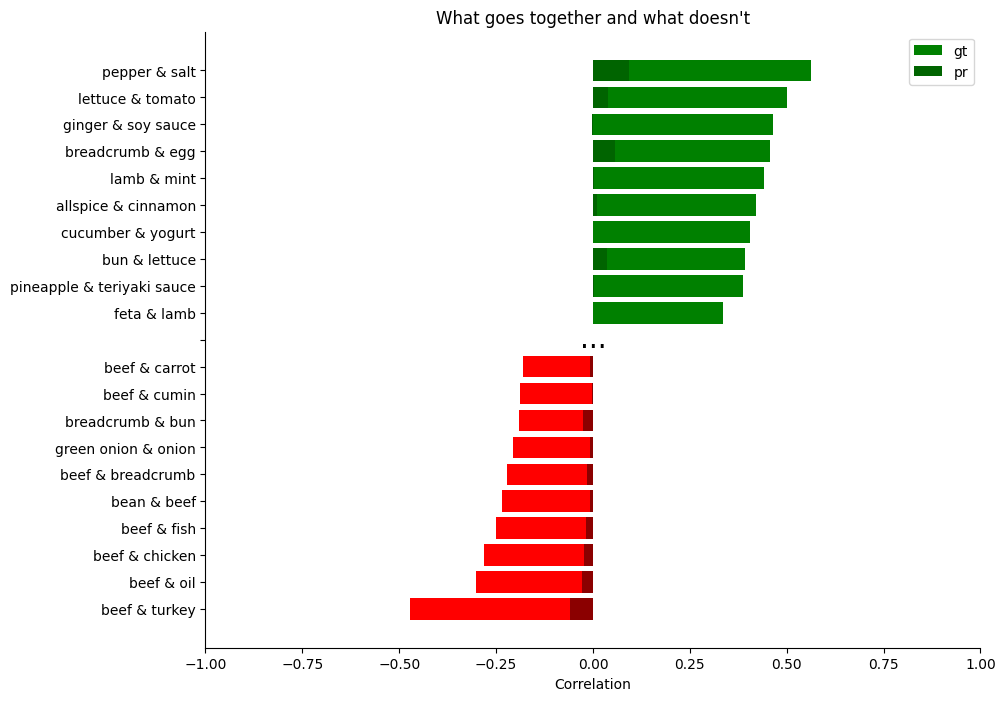

In [110]:
top_5 = pairs_sorted[:10]
bottom_5 = pairs_sorted[-10:]

top_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in top_5]
top_values_gt = [p[2] for p in top_5]
top_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in top_5]

bottom_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in bottom_5]
bottom_values_gt = [p[2] for p in bottom_5]
bottom_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in bottom_5]

combined_labels = top_labels + [' '] + bottom_labels

fig, ax = plt.subplots(figsize=(10, 8))

# Bars for top 5
ax.barh(range(len(top_labels)), top_values_gt, color='green', label = 'gt')
ax.barh(range(len(top_labels)), top_values_pr, color='darkgreen', label = 'pr')
# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_gt, color='red')
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_pr, color='darkred')

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()

plt.title('What goes together and what doesn\'t'); 

## 1.3. Bit-flip diffusion - works

In [3]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
gt_mask = jnp.array(recipes>0, dtype='int32')
with open('params/bitflip_mask_samples.npy', 'rb') as f:
    samples = pickle.load(f)

### 1.3.1. Some samples for a quick glance

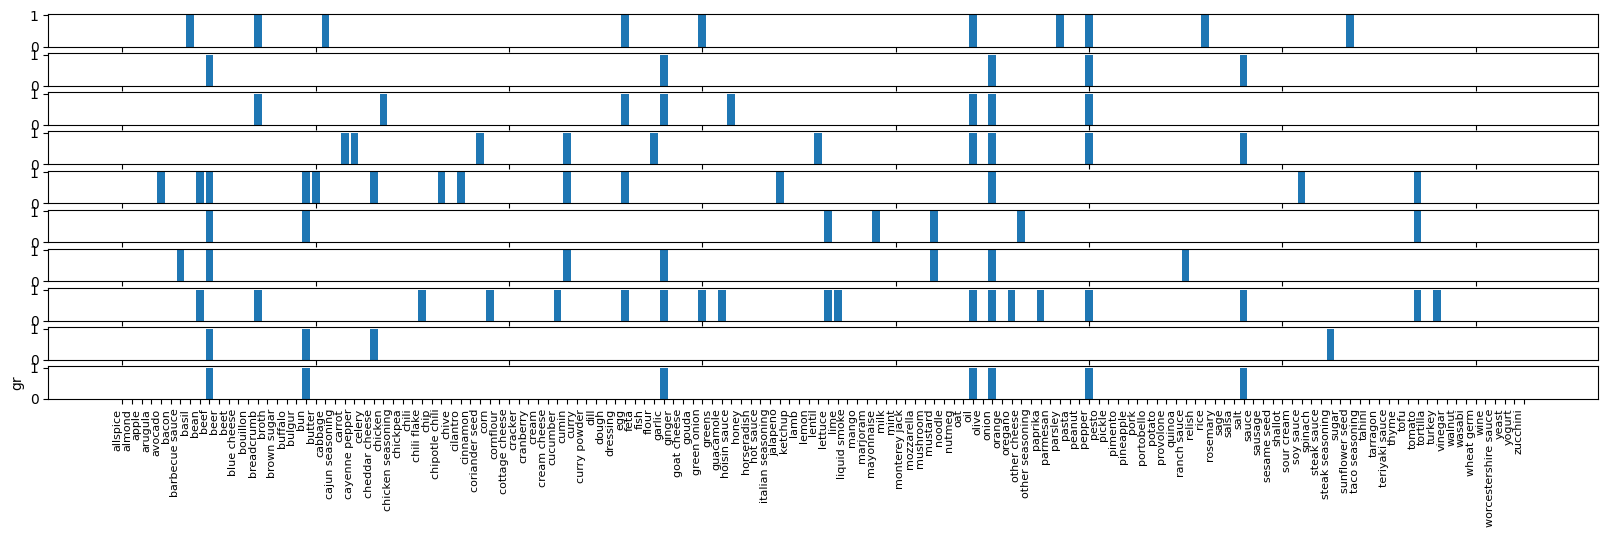

In [9]:
n = 10
plt.figure(figsize=(20,0.5*n))
for i in range(n):
    plt.subplot(n, 1, i+1)
    plt.bar(np.arange(samples.shape[1]), samples[i])

plt.gca().set_xticks(range(len(ingr_names)))
plt.gca().set_xticklabels(ingr_names, rotation=90, ha='right', fontsize=8); 
plt.ylabel('gr'); 

### 1.3.2. Number of ingredients per recipe

In [42]:
print('Average number of ingredients: ')
n_ing_gt = np.mean(gt_mask.sum(axis=1))
n_ing_pr = np.mean(samples.sum(axis=1))
print('Data: ', n_ing_gt)
print('Model: ', n_ing_pr)
print('Relative error: ', np.abs(n_ing_pr-n_ing_gt)/n_ing_gt*100)

Average number of ingredients: 
Data:  9.291967509025271
Model:  9.585
Relative error:  3.1536108008353185


Overlap: 88.08404332129965%


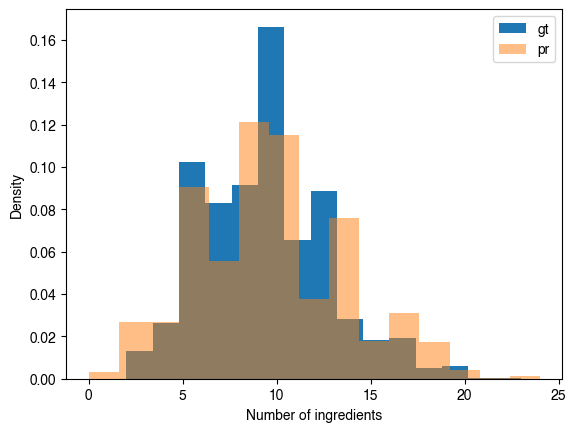

In [5]:
# Distribution of number of ingredients|
def overlap_and_tv(x, y, bins='auto'):
    # histogram-based TV; robust to different sample sizes
    # shared bin edges from pooled data
    hist_range = (min(np.min(x), np.min(y)), max(np.max(x), np.max(y)))
    px, edges = np.histogram(x, bins=bins, range=hist_range, density=True)
    py, _     = np.histogram(y, bins=edges, density=True)
    # convert densities to bin probabilities
    widths = np.diff(edges)
    Px, Py = px*widths, py*widths
    tv = 0.5*np.sum(np.abs(Px - Py))
    ovl = 1 - tv
    return ovl, tv

ovl, tv = overlap_and_tv(gt_mask.sum(axis=1), samples.sum(axis=1))
print(f"Overlap: {ovl*100}%")

plt.hist(gt_mask.sum(axis=1), density=True, label='gt', bins=15)
plt.hist(samples.sum(axis=1), density=True, label='pr', alpha=0.5, bins=15)

plt.xlabel('Number of ingredients')
plt.ylabel('Density')

plt.legend(); 

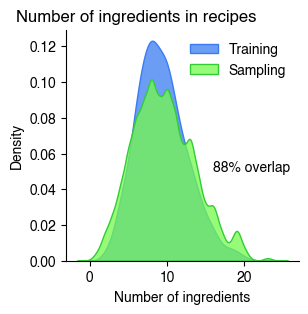

In [33]:
plt.figure(figsize=(3,3))
sns.kdeplot(gt_mask.sum(axis=1), fill=True, color=gt_color, label="Training", alpha=0.75)
sns.kdeplot(samples.sum(axis=1), fill=True, color=pr_color, label="Sampling", alpha=0.75, edgecolor='limegreen')

plt.xlabel('Number of ingredients')
plt.ylabel('Density')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False); 
plt.text(x=16, y=0.05, s=f"{ovl*100:.0f}% overlap")
plt.title(f"Number of ingredients in recipes", x=0.3)
plt.savefig("figs/ningr.pdf", bbox_inches='tight')

Maximum absolute difference: 7.574133574007225 %
Maximum relative difference in the top 10: 15.107957639939473 %
Mean absolute error: 0.9346770683942437 %


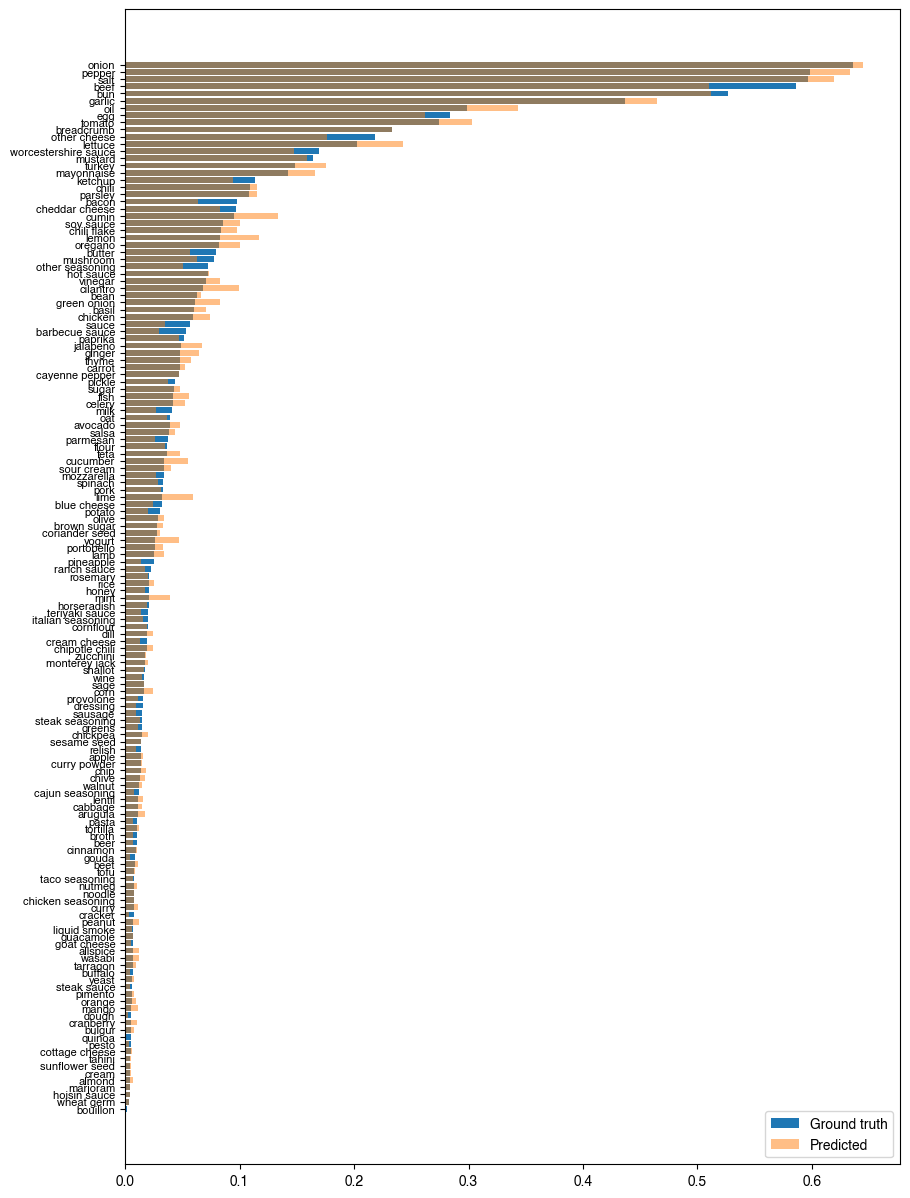

In [25]:
plt.figure(figsize=(10,15))

gt_probs = gt_mask.sum(axis=0)/len(gt_mask)
idx_sorted = np.argsort(gt_probs)
gt_sorted = gt_probs[idx_sorted]
plt.barh(np.arange(gt_mask.shape[1]), gt_sorted, label='Ground truth')

pr_probs = samples.sum(axis=0)/len(samples)
pr_sorted = pr_probs[idx_sorted]
plt.barh(np.arange(gt_mask.shape[1]), pr_sorted, label='Predicted', alpha=0.5)

plt.gca().set_yticks(range(len(ingr_names)))
plt.gca().set_yticklabels(ingr_names[idx_sorted], ha='right', fontsize=8); 
plt.legend(loc='lower right')

max_diff = np.max(np.abs(gt_sorted-pr_sorted))*100
print(f"Maximum absolute difference: {max_diff} %")
print(f"Maximum relative difference in the top 10: {np.max((np.abs(gt_sorted-pr_sorted)/gt_sorted)[-10:])*100} %")


mean_diff = np.mean(np.abs(gt_sorted-pr_sorted))*100
print(f"Mean absolute error: {mean_diff} %")

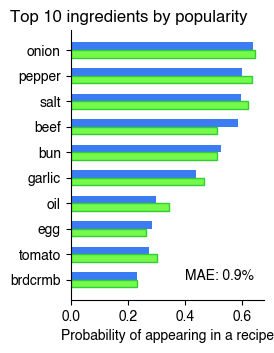

In [32]:
gt_concise = gt_sorted[-10:]
pr_concise = pr_sorted[-10:]
ingr_names_concise = ingr_names[idx_sorted][-10:]
ingr_names_concise[0] = 'brdcrmb'
n = len(gt_concise)

plt.figure(figsize=(2.5,3.5))

bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions

# Shift the bars so they are adjacent
plt.barh(y_pos + bar_width/2, gt_concise, height=bar_width, label='Train. data', color=gt_color)
plt.barh(y_pos - bar_width/2, pr_concise, height=bar_width, label='Samples', color=pr_color, edgecolor='limegreen')

plt.gca().set_yticks(y_pos)
plt.gca().set_yticklabels(ingr_names_concise, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.legend(loc='lower right', frameon=False)
plt.xlabel('Probability of appearing in a recipe')
# plt.ylabel('Top 10 ingredients by popularity')
# plt.title(f'Mean absolute error: {mean_diff:.1f}%', x=0.2)
plt.title('Top 10 ingredients by popularity', x=0.3)
plt.text(x=0.4, y=0, s=f'MAE: {mean_diff:.1f}%')
plt.savefig('figs/prob_appearing.pdf', bbox_inches='tight')

### 1.3.3. Conditional probabilities

In [155]:
gt_correlation_matrix = np.corrcoef(gt_mask, rowvar=False)
pr_correlation_matrix = np.corrcoef(samples, rowvar=False)

# Sort by most highly correlated pairs
pairs = []
n = gt_correlation_matrix.shape[0]
for i in range(n):
    for j in range(i+1, n):  # j>i to avoid duplicates and diagonal
        corr_value = gt_correlation_matrix[i, j]
        pairs.append((i, j, corr_value))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Most positively and most negatively correlated items")
top_and_bottom = pairs_sorted[:10] + pairs_sorted[-10:]
print(f"{'i':<5} {'j':<5} {'ingr_i':<20} {'ingr_j':<20} {'correlation (gt)':<10} {'correlation (pr)':<10}")
print("-"*70)
for i,j,corr in top_and_bottom:
    print(f"{i:<5} {j:<5} {ingr_names[i]:<20} {ingr_names[j]:<20} {corr:<10.4f} {pr_correlation_matrix[i,j]:<10.4f}")

Most positively and most negatively correlated items
i     j     ingr_i               ingr_j               correlation (gt) correlation (pr)
----------------------------------------------------------------------
100   116   pepper               salt                 0.5620     0.6244    
73    134   lettuce              tomato               0.5013     0.5366    
57    122   ginger               soy sauce            0.4649     0.5029    
14    52    breadcrumb           egg                  0.4567     0.5159    
70    80    lamb                 mint                 0.4404     0.5606    
0     36    allspice             cinnamon             0.4215     0.6969    
45    144   cucumber             yogurt               0.4040     0.5092    
19    73    bun                  lettuce              0.3913     0.4831    
104   131   pineapple            teriyaki sauce       0.3883     0.2585    
53    70    feta                 lamb                 0.3364     0.4640    
9     23    beef            

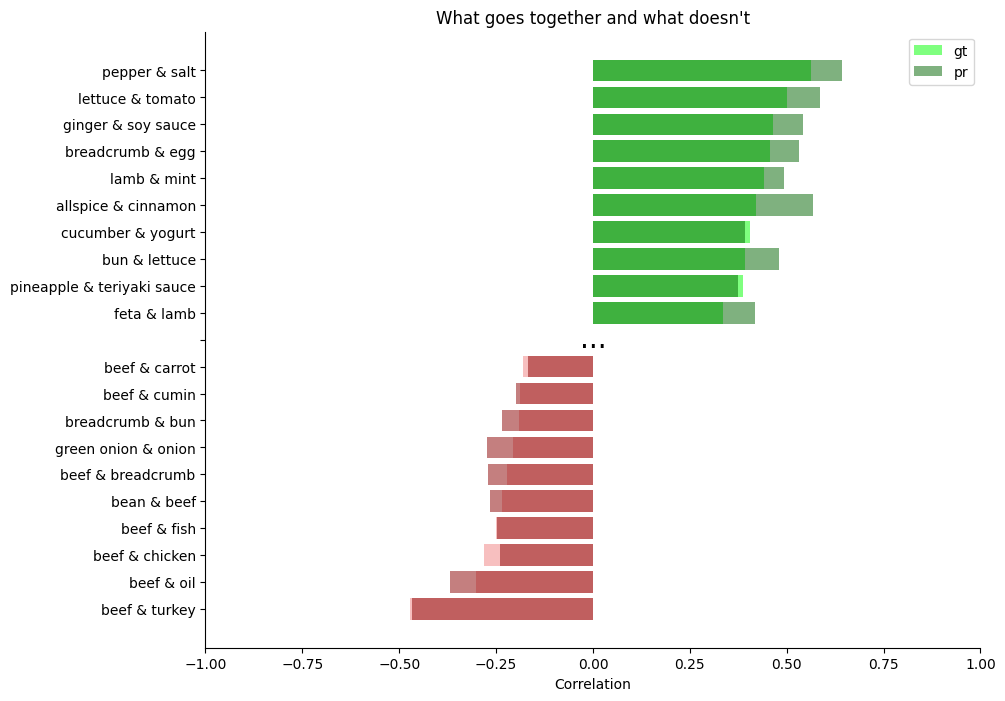

In [ ]:
top_5 = pairs_sorted[:10]
bottom_5 = pairs_sorted[-10:]

top_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in top_5]
top_values_gt = [p[2] for p in top_5]
top_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in top_5]

bottom_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in bottom_5]
bottom_values_gt = [p[2] for p in bottom_5]
bottom_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in bottom_5]

combined_labels = top_labels + [' '] + bottom_labels

fig, ax = plt.subplots(figsize=(10, 8))

# Bars for top 5
ax.barh(range(len(top_labels)), top_values_gt, color='lime', label = 'gt', alpha=0.5)
ax.barh(range(len(top_labels)), top_values_pr, color='darkgreen', label = 'pr', alpha=0.5)
# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_gt, color='lightcoral', alpha=0.5)
ax.barh(range(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels)), bottom_values_pr, color='darkred', alpha=0.5)

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()

plt.title('What goes together and what doesn\'t'); 

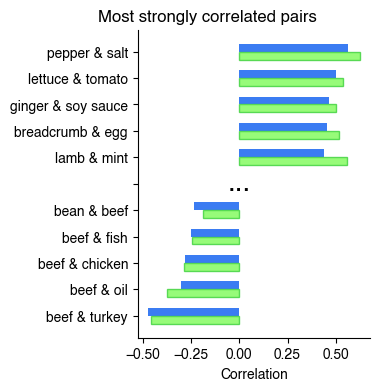

In [184]:
top_5 = pairs_sorted[:5]
bottom_5 = pairs_sorted[-5:]

top_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in top_5]
top_values_gt = [p[2] for p in top_5]
top_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in top_5]

bottom_labels = [f"{ingr_names[p[0]]} & {ingr_names[p[1]]}" for p in bottom_5]
bottom_values_gt = [p[2] for p in bottom_5]
bottom_values_pr = [pr_correlation_matrix[i,j] for i,j,_ in bottom_5]

combined_labels = top_labels + [' '] + bottom_labels

fig, ax = plt.subplots(figsize=(3, 4))


# Bars for top 5
n = len(top_labels)
bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions
ax.barh(y_pos - bar_width/2, top_values_gt, height=bar_width, color=gt_color, label = 'Train. data', )
ax.barh(y_pos + bar_width/2, top_values_pr, height=bar_width, color=pr_color, edgecolor='limegreen', label = 'Samples', alpha=0.75)

# Bars for bottom 5, offset by len(top_labels) + 1 (for ellipsis)
y_pos = np.arange(len(top_labels) + 1, len(top_labels) + 1 + len(bottom_labels))  # original y positions
ax.barh(y_pos - bar_width/2, bottom_values_gt, height=bar_width, color=gt_color)
ax.barh(y_pos + bar_width/2, bottom_values_pr, height=bar_width, color=pr_color, edgecolor='limegreen', alpha=0.75)

# Set yticks with combined labels, placing empty label for ellipsis position
yticks_pos = list(range(len(combined_labels)))
yticks_labels = combined_labels.copy()
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels)

# Add ellipsis text between groups
ax.text(0.0, len(top_labels), '...', fontsize=20, ha='center', va='center')

# Axis labels and title
ax.set_xlabel('Correlation')
# ax.set_xlim(-1, 1)
ax.invert_yaxis()  # So highest correlation is at top

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# ax.legend(frameon=False)

plt.title('Most strongly correlated pairs', x=0.3); 
plt.savefig('figs/correlation_pairs.pdf', bbox_inches='tight')

# 2. Value models

## 2.1. Diffusion

In [34]:
from train_diffusion_val import *
rng = random.PRNGKey(2025)

with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_recipes = len(recipes)
n_ingr = len(ingr_names)
gt_mask = jnp.array(recipes>0, dtype='int32')

with open(f'params/diff_value_params.npy', 'rb') as f:
    params, fitted_lambdas, means_stds, train_data, val_data = pickle.load(f)

# with open(f'params/diff_value_samples.npy', 'rb') as f:
#     samples = pickle.load(f)

val_vals, val_mask = val_data
val_mask = jnp.array(val_mask, dtype='int32')
score_model = ApproximateScore(n_hidden=n_hidden)
trained_score = lambda x, t, mask: score_model.apply(params, x, t, mask)
samples = reverse_sde(rng, n_ingr, drift, dispersion, trained_score, val_mask).block_until_ready()


unnormalized_pr = []
unnormalized_gt = []
for i in range(n_ingr):
    ingr, fitted_lambda, (mean, std) = samples[:,i], fitted_lambdas[i], means_stds[i]
    ingr = ingr*std + mean
    ingr = inv_boxcox(ingr, fitted_lambda)
    unnormalized_pr.append(ingr)

    ingr = val_vals[:,i]
    ingr = ingr*std + mean
    ingr = inv_boxcox(ingr, fitted_lambda)
    unnormalized_gt.append(ingr)
unnormalized_pr = np.array(unnormalized_pr).T * val_mask
unnormalized_gt = np.array(unnormalized_gt).T

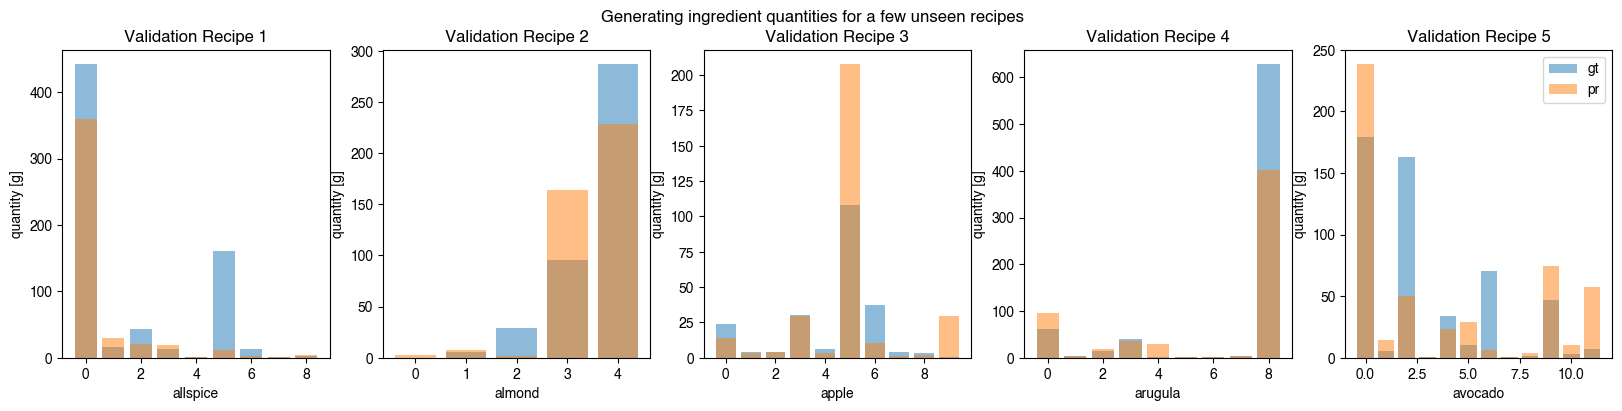

In [35]:
plt.figure(figsize=(20,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.title(f'Validation Recipe {i+1}')
    xs = np.arange(sum(val_mask[i]))
    y_idx = val_mask[i]>0
    plt.bar(xs, unnormalized_gt[i,y_idx], alpha = 0.5, label = 'gt')
    plt.bar(xs, unnormalized_pr[i,y_idx], alpha = 0.5, label = 'pr')

    plt.xlabel(ingr_names[i])
    plt.ylabel('quantity [g]')

plt.suptitle('Generating ingredient quantities for a few unseen recipes'); 
plt.legend()

## Distributions of the quantities

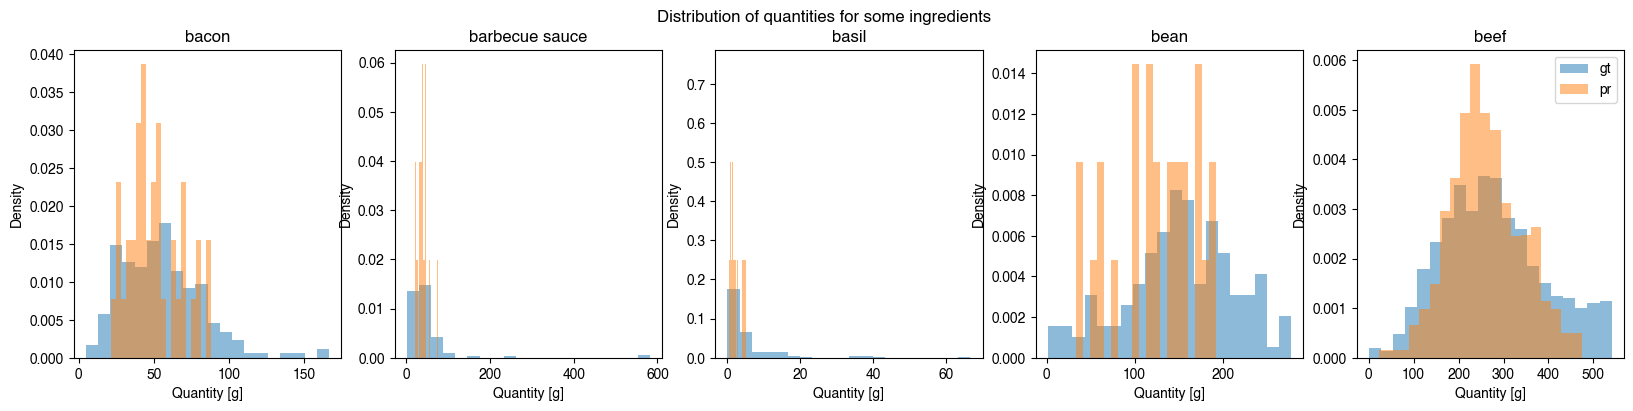

In [36]:
plt.figure(figsize=(20,4))

for i_ingr in range(5):
    plt.subplot(1,5,i_ingr+1)
    plt.title(f'Ingredient {i_ingr+1}')
    i_ingr+= 5
    # plt.hist(unnormalized_gt[unnormalized_gt[:,i_ingr]>0, i_ingr], bins=20, label='gt', density=True, alpha=0.5); 
    plt.hist(recipes[recipes[:,i_ingr]>0, i_ingr], bins=20, label='gt', density=True, alpha=0.5)
    plt.hist(unnormalized_pr[unnormalized_pr[:,i_ingr]>0, i_ingr], bins=20, label='pr', density=True, alpha=0.5); 

    plt.xlabel('Quantity [g]')
    plt.ylabel('Density')
    plt.title(ingr_names[i_ingr])

plt.suptitle('Distribution of quantities for some ingredients')
plt.legend()


In [37]:
gt_qty = []
pr_qty = []
for i in range(samples.shape[1]):
    temp = recipes[:,i]
    temp = temp[temp>0]
    gt_qty.append(np.mean(temp))

    temp = unnormalized_pr[:,i]
    temp = temp[temp>0]
    pr_qty.append(np.mean(temp))
gt_qty = np.array(gt_qty)
pr_qty = np.array(pr_qty)
pr_qty = np.nan_to_num(pr_qty, nan=0)

idx_sorted = np.argsort(gt_qty)
gt_sorted = gt_qty[idx_sorted]
pr_sorted = pr_qty[idx_sorted]

gt_concise = gt_sorted[-10:]
pr_concise = pr_sorted[-10:]
n = len(gt_concise)

In [38]:
mean_diff = np.mean(np.abs(gt_sorted-pr_sorted))

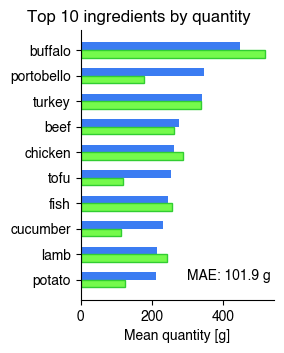

In [42]:
plt.figure(figsize=(2.5,3.5))
# plt.barh(np.arange(n), gt_concise, label='Ground truth', color=gt_color)
# plt.barh(np.arange(n), pr_concise, label='Predicted', alpha=0.75, color=pr_color, edgecolor='limegreen')

bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions
plt.barh(y_pos + bar_width/2, gt_concise, height=bar_width, label='Train. data', color=gt_color)
plt.barh(y_pos - bar_width/2, pr_concise, height=bar_width, label='Samples', color=pr_color, edgecolor='limegreen')

plt.gca().set_yticks(range(n))
plt.gca().set_yticklabels(ingr_names[idx_sorted][-10:], ha='right'); 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.legend(loc='lower right', frameon=False)
plt.xlabel('Mean quantity [g]')
# plt.ylabel('Top 10 ingredients by quantity')
# plt.title(f'Mean absolute error: {mean_diff:.1f} g', x=0.2)
plt.title('Top 10 ingredients by quantity', x=0.3)
plt.text(x=300, y=0, s=f'MAE: {mean_diff:.1f} g')
plt.savefig('figs/mean_qty.pdf', bbox_inches='tight')

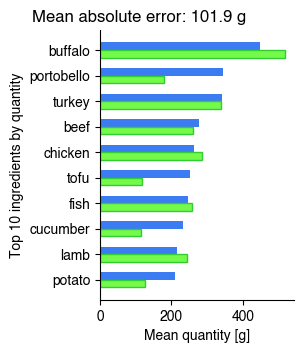

In [40]:
plt.figure(figsize=(2.5,3.5))
# plt.barh(np.arange(n), gt_concise, label='Ground truth', color=gt_color)
# plt.barh(np.arange(n), pr_concise, label='Predicted', alpha=0.75, color=pr_color, edgecolor='limegreen')

bar_width = 0.3  # width of each bar
y_pos = np.arange(n)  # original y positions
plt.barh(y_pos + bar_width/2, gt_concise, height=bar_width, label='Train. data', color=gt_color)
plt.barh(y_pos - bar_width/2, pr_concise, height=bar_width, label='Samples', color=pr_color, edgecolor='limegreen')

plt.gca().set_yticks(range(n))
plt.gca().set_yticklabels(ingr_names[idx_sorted][-10:], ha='right'); 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.legend(loc='lower right', frameon=False)
plt.xlabel('Mean quantity [g]')
plt.ylabel('Top 10 ingredients by quantity')
plt.title(f'Mean absolute error: {mean_diff:.1f} g', x=0.2)
plt.savefig('figs/mean_qty.pdf', bbox_inches='tight')